## Análise Complementar

Este notebook contém análises complementares além das questões obrigatórias do desafio, com o objetivo de aprofundar a exploração dos dados e gerar insights adicionais.

---

In [1]:
import json
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.size':        11,
})

# ── Dados ──────────────────────────────────────────────────────────────────
df_vendas   = pd.read_csv('../data/raw/vendas_2023_2024.csv')
df_produtos = pd.read_csv('../data/raw/produtos_raw.csv')

with open('../data/raw/clientes_crm.json', encoding='utf-8') as f:
    df_clientes = pd.DataFrame(json.load(f))

def parse_date(s):
    for fmt in ('%Y-%m-%d', '%d-%m-%Y'):
        try: return pd.to_datetime(s, format=fmt)
        except: pass

df_vendas['sale_date'] = df_vendas['sale_date'].apply(parse_date)

def normalizar_categoria(texto):
    t = texto.lower().replace(' ', '')
    t = ''.join(c for c in unicodedata.normalize('NFD', t) if unicodedata.category(c) != 'Mn')
    if t.startswith('elet'):                       return 'Eletronicos'
    if t.startswith('prop'):                       return 'Propulsao'
    if t.startswith('anc') or t.startswith('enc'): return 'Ancoragem'
    return t

df_produtos['categoria'] = df_produtos['actual_category'].apply(normalizar_categoria)
df_produtos['price']     = df_produtos['price'].str.replace('R$ ', '', regex=False).astype(float)
df_produtos = df_produtos.drop_duplicates(subset='code', keep='first')

df = df_vendas.merge(df_produtos[['code','name','categoria']], left_on='id_product', right_on='code', how='left')
print('Dados carregados com sucesso')


Dados carregados com sucesso


---
## 1. Visão Geral do Negócio

Panorama do faturamento nos dois anos analisados, evolução mensal e distribuição por categoria.

=== Faturamento por Ano ===
  2023: R$ 1,288,827,295
  2024: R$ 1,321,452,216
  Crescimento: +2.5%


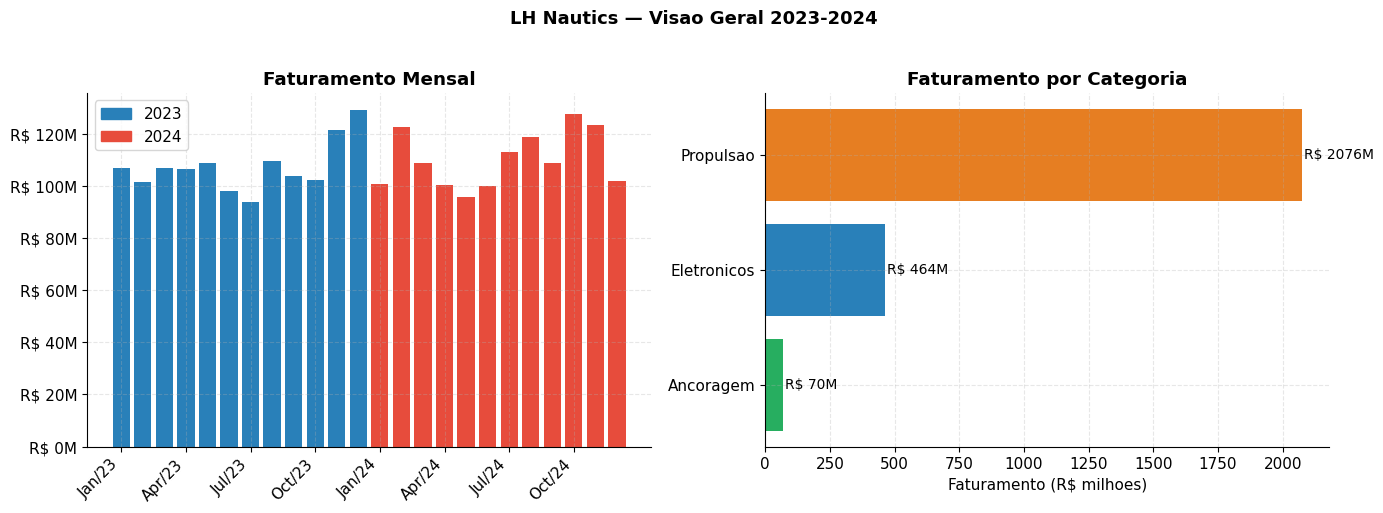

In [ ]:
df_vendas['ano'] = df_vendas['sale_date'].dt.year
df_vendas['mes'] = df_vendas['sale_date'].dt.to_period('M').astype(str)

rev_ano = df_vendas.groupby('ano')['total'].sum()
crescimento = (rev_ano[2024] - rev_ano[2023]) / rev_ano[2023] * 100

print('=== Faturamento por Ano ===')
for ano, val in rev_ano.items():
    print(f'  {ano}: R$ {val:,.0f}')
print(f'  Crescimento: +{crescimento:.1f}%')

# Gráfico 1: Faturamento mensal
monthly = df_vendas.groupby('mes')['total'].sum().reset_index()
monthly['mes'] = pd.to_datetime(monthly['mes'])
monthly = monthly.sort_values('mes')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mensal
cores = ['#2980b9' if str(m.year) == '2023' else '#e74c3c' for m in monthly['mes']]
axes[0].bar(range(len(monthly)), monthly['total'] / 1e6, color=cores, width=0.8)
axes[0].set_xticks(range(0, len(monthly), 3))
axes[0].set_xticklabels(
    [m.strftime('%b/%y') for m in monthly['mes'][::3]], rotation=45, ha='right'
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.0f}M'))
axes[0].set_title('Faturamento Mensal', fontweight='bold')
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#2980b9', label='2023'),
    plt.Rectangle((0,0),1,1, color='#e74c3c', label='2024')
])

# Por categoria
cat_rev = df.groupby('categoria')['total'].sum().sort_values()
cores_cat = ['#27ae60', '#2980b9', '#e67e22']
axes[1].barh(cat_rev.index, cat_rev.values / 1e6, color=cores_cat)
for i, (cat, val) in enumerate(cat_rev.items()):
    axes[1].text(val/1e6 + 5, i, f'R$ {val/1e6:.0f}M', va='center', fontsize=10)
axes[1].set_xlabel('Faturamento (R$ milhoes)')
axes[1].set_title('Faturamento por Categoria', fontweight='bold')

plt.suptitle('LH Nautics — Visao Geral 2023-2024', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 2. Análise de Prejuízo por Produto

Produtos vendidos abaixo do custo de importação (custo USD × câmbio do dia).
Os dados de prejuízo foram calculados na Questão 4 e estão salvos em `data/processed/prejuizo_por_produto.csv`.

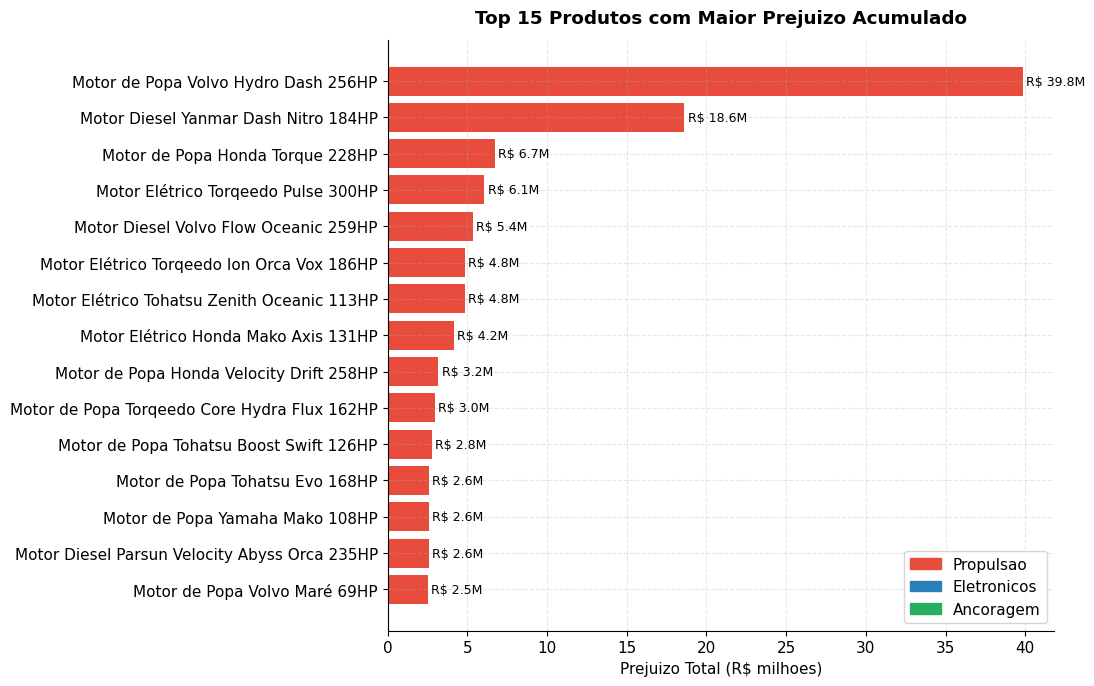

Total de produtos com prejuizo: 150
Prejuizo total acumulado: R$ 182,144,539


In [ ]:
try:
    df_prej = pd.read_csv('../data/processed/prejuizo_por_produto.csv')
    df_prej = df_prej[df_prej['prejuizo_total'] > 0].sort_values('prejuizo_total', ascending=False)
    df_prej = df_prej.merge(df_produtos[['code','name','categoria']], left_on='id_product', right_on='code', how='left')

    top15 = df_prej.head(15).sort_values('prejuizo_total')

    fig, ax = plt.subplots(figsize=(11, 7))

    cores_cat = {'Propulsao': '#e74c3c', 'Eletronicos': '#2980b9', 'Ancoragem': '#27ae60'}
    cores = [cores_cat.get(c, '#95a5a6') for c in top15['categoria']]

    bars = ax.barh(top15['name'], top15['prejuizo_total'] / 1e6, color=cores)
    for bar in bars:
        v = bar.get_width()
        ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
                f'R$ {v:.1f}M', va='center', fontsize=9)

    ax.set_xlabel('Prejuizo Total (R$ milhoes)')
    ax.set_title('Top 15 Produtos com Maior Prejuizo Acumulado', fontweight='bold', pad=12)
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, color='#e74c3c', label='Propulsao'),
        plt.Rectangle((0,0),1,1, color='#2980b9', label='Eletronicos'),
        plt.Rectangle((0,0),1,1, color='#27ae60', label='Ancoragem'),
    ], loc='lower right')

    plt.tight_layout()
    plt.show()

    print(f'Total de produtos com prejuizo: {len(df_prej)}')
    print(f'Prejuizo total acumulado: R$ {df_prej["prejuizo_total"].sum():,.0f}')

except FileNotFoundError:
    print('Arquivo prejuizo_por_produto.csv nao encontrado.')
    print('Rode o notebook 04_custos_prejuizo.ipynb primeiro.')


---
## 3. Clientes Fiéis — Top 10 por Ticket Médio

Clientes com maior ticket médio por transação que compraram em 3 ou mais categorias distintas.

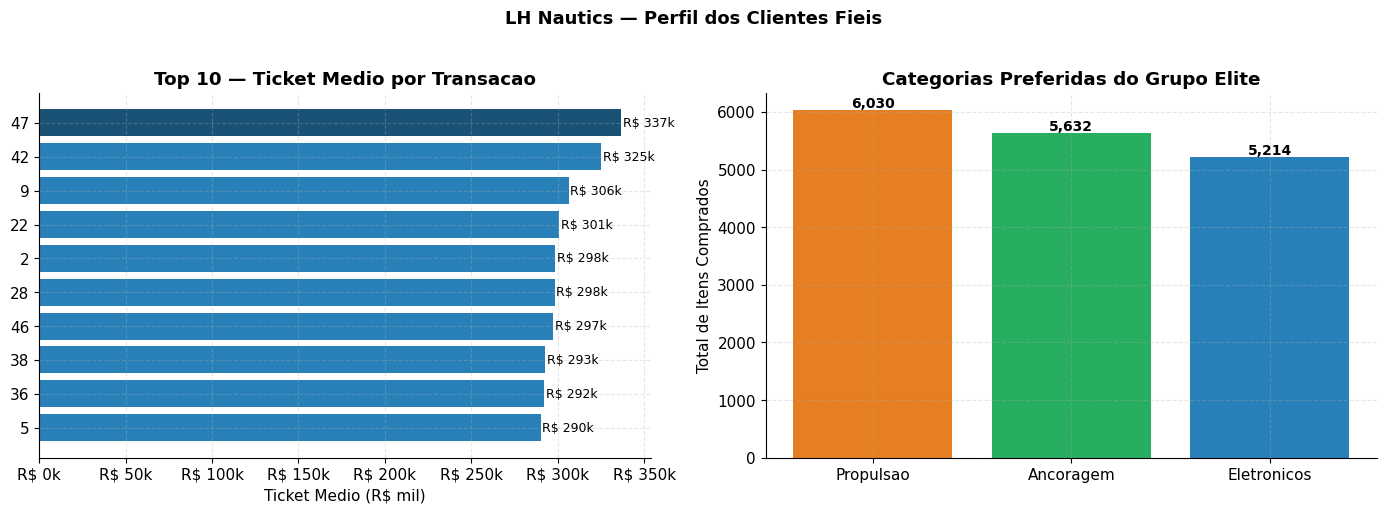

In [ ]:
metricas = df.groupby('id_client').agg(
    faturamento_total = ('total',     'sum'),
    frequencia        = ('id',        'count'),
    diversidade       = ('categoria', 'nunique')
).reset_index()
metricas['ticket_medio'] = metricas['faturamento_total'] / metricas['frequencia']

top10 = (
    metricas[metricas['diversidade'] >= 3]
    .sort_values(['ticket_medio', 'id_client'], ascending=[False, True])
    .head(10).reset_index(drop=True)
)
top10.index += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ticket medio
cores = ['#1a5276' if i == 1 else '#2980b9' for i in range(1, 11)]
axes[0].barh(
    top10['id_client'].astype(str),
    top10['ticket_medio'] / 1e3,
    color=cores
)
axes[0].invert_yaxis()
axes[0].set_xlabel('Ticket Medio (R$ mil)')
axes[0].set_title('Top 10 — Ticket Medio por Transacao', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.0f}k'))
for bar in axes[0].patches:
    v = bar.get_width()
    axes[0].text(v + 1, bar.get_y() + bar.get_height()/2,
                 f'R$ {v:.0f}k', va='center', fontsize=9)

# Categoria mais comprada pelo grupo elite
ids_elite = top10['id_client'].tolist()
df_elite_cat = df[df['id_client'].isin(ids_elite)].groupby('categoria')['qtd'].sum().sort_values(ascending=False)
cores_cat2 = ['#e67e22', '#27ae60', '#2980b9']
axes[1].bar(df_elite_cat.index, df_elite_cat.values, color=cores_cat2)
for i, (cat, val) in enumerate(df_elite_cat.items()):
    axes[1].text(i, val + 50, f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Total de Itens Comprados')
axes[1].set_title('Categorias Preferidas do Grupo Elite', fontweight='bold')

plt.suptitle('LH Nautics — Perfil dos Clientes Fieis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 4. Sazonalidade — Média de Vendas por Dia da Semana

Considerando **todos os dias do período**, inclusive os dias sem venda (valor = 0).

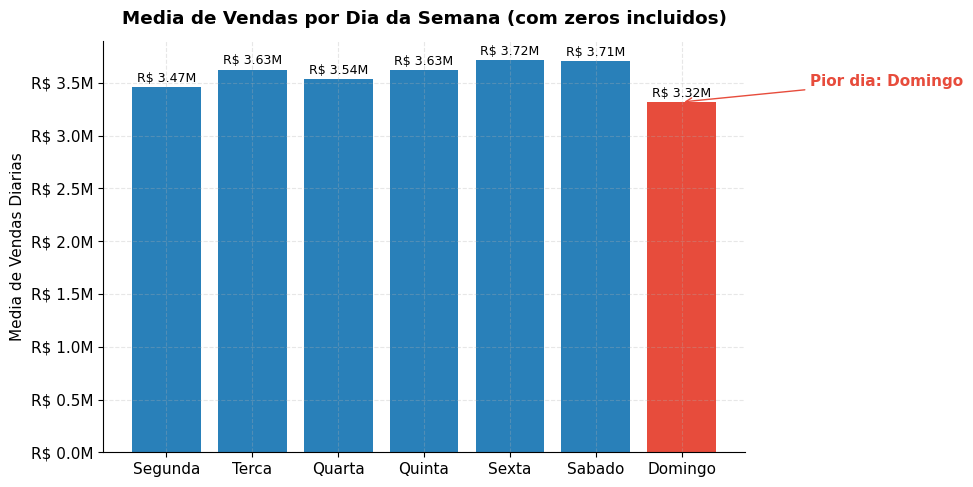

In [ ]:
todas_datas = pd.date_range(df_vendas['sale_date'].min(), df_vendas['sale_date'].max(), freq='D')
df_cal = pd.DataFrame({'data': todas_datas})
daily  = df_vendas.groupby(df_vendas['sale_date'].dt.date)['total'].sum().reset_index()
daily.columns = ['data', 'total']
daily['data'] = pd.to_datetime(daily['data'])

df_cal = df_cal.merge(daily, on='data', how='left').fillna(0)
df_cal['dia_semana'] = df_cal['data'].dt.dayofweek  # 0=Seg

nomes_dias = {0:'Segunda',1:'Terca',2:'Quarta',3:'Quinta',4:'Sexta',5:'Sabado',6:'Domingo'}
df_cal['dia_nome'] = df_cal['dia_semana'].map(nomes_dias)

weekly = (
    df_cal.groupby(['dia_semana','dia_nome'])['total']
    .mean().reset_index().sort_values('dia_semana')
)

pior_idx = weekly['total'].idxmin()
cores = ['#e74c3c' if i == pior_idx else '#2980b9' for i in weekly.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(weekly['dia_nome'], weekly['total'] / 1e6, color=cores)

for bar in bars:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f'R$ {v:.2f}M', ha='center', va='bottom', fontsize=9)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.1f}M'))
ax.set_ylabel('Media de Vendas Diarias')
ax.set_title('Media de Vendas por Dia da Semana (com zeros incluidos)', fontweight='bold', pad=12)

pior_dia = weekly.loc[pior_idx, 'dia_nome']
ax.annotate(f'Pior dia: {pior_dia}',
            xy=(pior_idx, weekly.loc[pior_idx,'total']/1e6),
            xytext=(pior_idx + 1.5, weekly.loc[pior_idx,'total']/1e6 + 0.15),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 5. Previsão de Demanda — Motor de Popa Yamaha Evo Dash 155HP

Modelo baseline: média móvel de 7 dias. Treino até 31/12/2023, teste em Janeiro/2024.

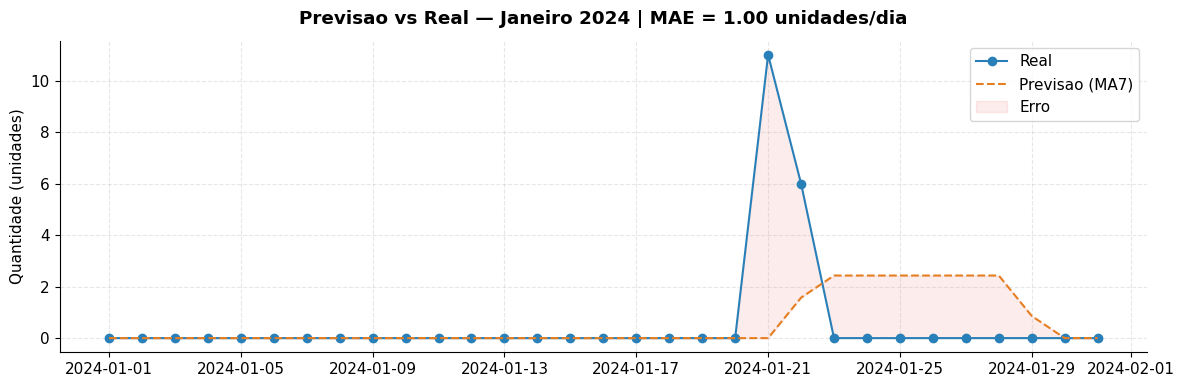

MAE: 0.9958 unidades/dia
Total real em Jan/2024: 17 unidades
Total previsto:         17.0 unidades


In [ ]:
PRODUTO_ID = 54
df_prod = df_vendas[df_vendas['id_product'] == PRODUTO_ID].copy()

serie_datas = pd.date_range('2023-01-01', '2024-01-31', freq='D')
df_serie = pd.DataFrame({'data': serie_datas})
diario = df_prod.groupby(df_prod['sale_date'].dt.date)['qtd'].sum().reset_index()
diario.columns = ['data','qtd']
diario['data'] = pd.to_datetime(diario['data'])
df_serie = df_serie.merge(diario, on='data', how='left').fillna(0)
df_serie['qtd'] = df_serie['qtd'].astype(int)
df_serie['ma7'] = df_serie['qtd'].shift(1).rolling(7, min_periods=1).mean().round(2)

teste = df_serie[df_serie['data'] >= '2024-01-01'].copy()
mae   = (teste['qtd'] - teste['ma7']).abs().mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(teste['data'], teste['qtd'],   label='Real',          color='#2980b9', marker='o', linewidth=1.5)
ax.plot(teste['data'], teste['ma7'],   label='Previsao (MA7)',color='#e67e22', linestyle='--', linewidth=1.5)
ax.fill_between(teste['data'], teste['qtd'], teste['ma7'], alpha=0.1, color='#e74c3c', label='Erro')
ax.set_title(f'Previsao vs Real — Janeiro 2024 | MAE = {mae:.2f} unidades/dia',
             fontweight='bold', pad=12)
ax.set_ylabel('Quantidade (unidades)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'MAE: {mae:.4f} unidades/dia')
print(f'Total real em Jan/2024: {teste["qtd"].sum()} unidades')
print(f'Total previsto:         {teste["ma7"].sum():.1f} unidades')


---
## 6. Sistema de Recomendação

Vitrine **'Quem comprou isso, também levou...'** baseada em similaridade de cosseno entre produtos.

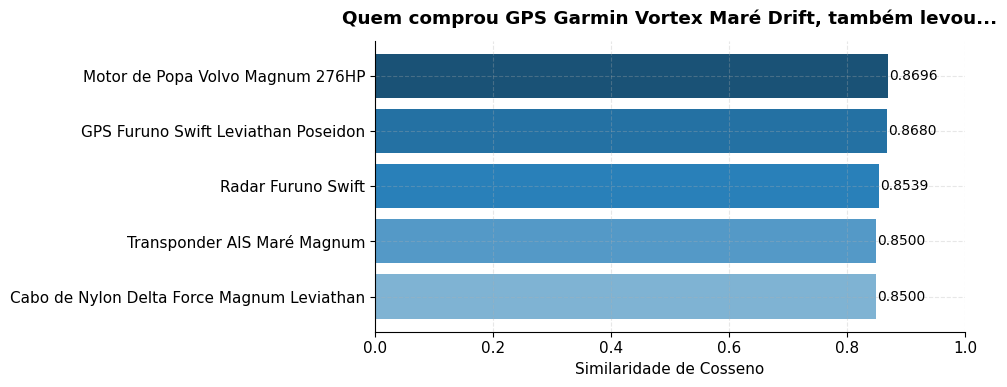

In [ ]:
TARGET_ID = 27  # GPS Garmin Vortex Maré Drift

df_int = df_vendas.groupby(['id_client','id_product'])['qtd'].sum().reset_index()
df_int['comprou'] = 1
matriz = df_int.pivot_table(index='id_client', columns='id_product', values='comprou', fill_value=0)

sim_matrix = cosine_similarity(matriz.T)
sim_df = pd.DataFrame(sim_matrix, index=matriz.columns, columns=matriz.columns)

ranking = (
    sim_df[TARGET_ID].drop(TARGET_ID)
    .sort_values(ascending=False).head(5).reset_index()
)
ranking.columns = ['id_produto', 'similaridade']
ranking = ranking.merge(df_produtos[['code','name']], left_on='id_produto', right_on='code').drop(columns='code')
ranking.index += 1

# Vitrine visual
fig, ax = plt.subplots(figsize=(10, 4))
cores = ['#1a5276','#2471a3','#2980b9','#5499c7','#7fb3d3']
bars = ax.barh(ranking['name'], ranking['similaridade'], color=cores)
for bar in bars:
    v = bar.get_width()
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('Similaridade de Cosseno')
ax.set_title('Quem comprou GPS Garmin Vortex Maré Drift, também levou...',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


---
## 7. Conclusões e Próximos Passos

### Principais achados

- **Crescimento consistente:** o faturamento cresceu de R$ 1,29B em 2023 para R$ 1,32B em 2024, alta de ~2,5%.
- **Propulsão domina:** a categoria representa ~80% da receita total, seguida de Eletrônicos (~18%) e Ancoragem (~2%).
- **Prejuízo oculto:** parte das vendas foi realizada abaixo do custo de importação (USD × câmbio do dia). Os produtos de propulsão de alto valor são os mais expostos à variação cambial.
- **Clientes fiéis:** os Top 10 clientes elite têm ticket médio entre R$ 290k e R$ 337k por transação, compram nas 3 categorias e têm frequência média de 200+ transações no período.
- **Domingo é o pior dia:** média de R$ 3,32M vs R$ 3,72M na Sexta-feira — diferença de ~12% que pode orientar estratégias de ativação ou promoções pontuais.
- **Demanda esparsa:** o Motor de Popa Yamaha Evo Dash tem vendas muito irregulares, tornando o baseline de MA7 insuficiente para planejamento de estoque.

### Próximos passos

1. **Câmbio como variável de risco:** criar alertas automáticos quando o câmbio ultrapassar o limiar de prejuízo para os produtos mais expostos.
2. **Modelo de demanda mais robusto:** para produtos de venda esparsa, explorar modelos como Croston ou Prophet, que lidam melhor com séries intermitentes.
3. **Enriquecer o CRM:** normalizar o campo `location` dos clientes para habilitar análise geográfica e identificar regiões com maior potencial de expansão.
4. **Corrigir e-mails inválidos:** 30 dos 49 clientes têm `#` no lugar de `@` — impede campanhas de e-mail marketing para o segmento de maior valor.
5. **Expandir o sistema de recomendação:** testar com matriz ponderada por quantidade (não apenas binária) e avaliar se melhora a qualidade das recomendações para itens de ancoragem.
